# Exploring DNF patterns, 2000–2024

This notebook explores the labeled dataset built in steps 1–2. **No modeling here** —
the goal is to see the shape of the data before deciding how to model it.

- Data: `data/processed/features.parquet` (one row per driver-race, with `dnf` and
  `dnf_category` labels from `src/labels.py`). Cars that never took the start are
  excluded from this table, and disqualified cars count as finished (flagged in
  `disqualified`) — see the step-2 revision notes in `EXPLANATION.md`.
- Every chart is also saved as a PNG under `reports/figures/`.

Run top to bottom (`jupyter nbconvert --execute` or Run All). Requires the packages
in `requirements.txt`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# Project palette (validated for color-vision safety on the light surface)
SURFACE = "#fcfcfb"   # chart background
INK     = "#0b0b0b"   # primary text
INK2    = "#52514e"   # secondary text
MUTED   = "#898781"   # axis labels / small annotations
GRID    = "#e1e0d9"   # hairline gridlines
BASE    = "#c3c2b7"   # axis baseline
BLUE    = "#2a78d6"   # series 1
ORANGE  = "#eb6834"   # series 2

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(ROOT / "data/processed/features.parquet")
circuit_names = (
    pd.read_parquet(ROOT / "data/processed/results.parquet")
    [["circuit_id", "circuit_name"]].drop_duplicates("circuit_id")
    .set_index("circuit_id")["circuit_name"]
)

def styled(figsize):
    """A figure/axes pair with recessive chrome: hairline grid, no box."""
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(BASE)
    ax.tick_params(colors=MUTED, labelcolor=INK2)
    return fig, ax

def save(fig, name):
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight", facecolor=SURFACE)
    print("saved", FIG_DIR / name)

print(f"{len(df):,} driver-race rows, {df.season.nunique()} seasons, "
      f"overall DNF rate {df.dnf.mean():.1%}")

10,039 driver-race rows, 25 seasons, overall DNF rate 22.6%


## 1. DNF rate by season

Share of all race entries that did not finish, per season. If reliability has
improved over time, the line should fall — and a falling line means *season (or
anything correlated with it) is a strong signal* a model will pick up.

saved /home/user/Formula-1-Retirement-Crash-Predictor/reports/figures/dnf_rate_by_season.png


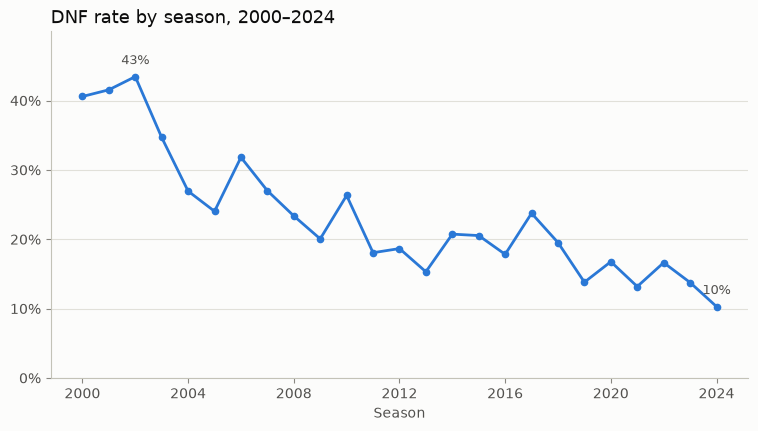

In [2]:
by_season = df.groupby("season")["dnf"].mean()

fig, ax = styled((9, 4.5))
ax.plot(by_season.index, by_season.values, color=BLUE, linewidth=2,
        marker="o", markersize=4.5)
ax.set_ylim(0, by_season.max() * 1.15)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_title("DNF rate by season, 2000–2024", color=INK, loc="left", fontsize=13)
ax.set_xlabel("Season", color=INK2)
ax.set_xticks(range(2000, 2025, 4))
for season in [by_season.idxmax(), 2024]:
    ax.annotate(f"{by_season[season]:.0%}", (season, by_season[season]),
                textcoords="offset points", xytext=(0, 9),
                ha="center", color=INK2, fontsize=9)
save(fig, "dnf_rate_by_season.png")
plt.show()

## 2. DNF rate by circuit

Historical DNF rate per circuit, all seasons pooled. Only circuits that hosted at
least **5 races** are shown — below that, one chaotic afternoon dominates the rate.
Street circuits and high-attrition tracks should float to the top.

saved /home/user/Formula-1-Retirement-Crash-Predictor/reports/figures/dnf_rate_by_circuit.png


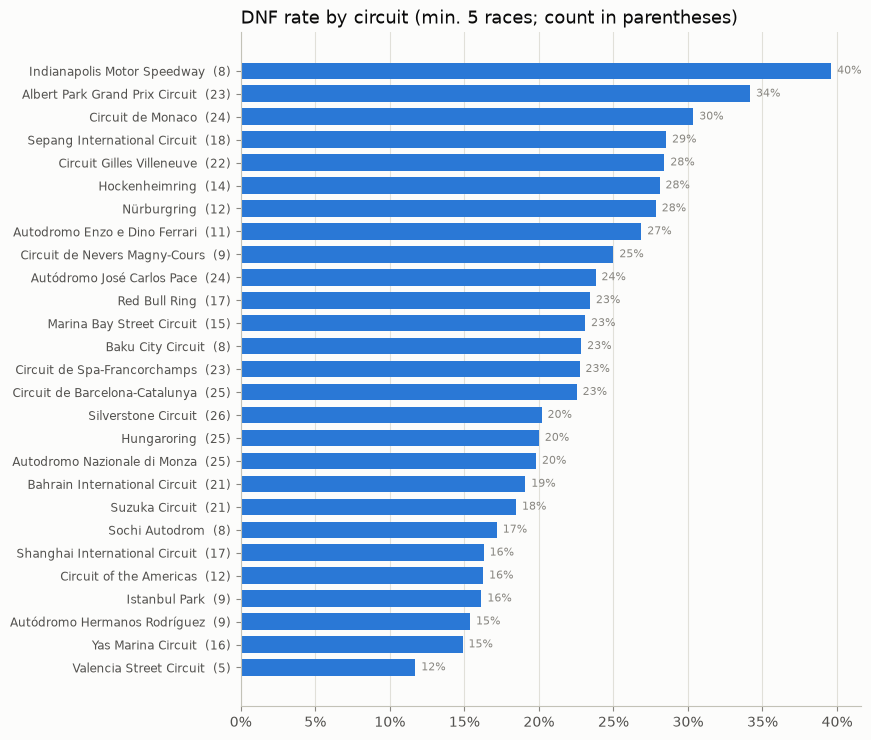

In [3]:
per_circuit = df.groupby("circuit_id")["dnf"].agg(["mean", "size"])
races_per_circuit = df.groupby("circuit_id")[["season", "round"]].nunique().min(axis=1)
n_races = df.drop_duplicates(["season", "round"]).groupby("circuit_id").size()
per_circuit["races"] = n_races
shown = per_circuit[per_circuit["races"] >= 5].sort_values("mean")

fig, ax = styled((8, 0.28 * len(shown) + 1.2))
labels = [f"{circuit_names[c]}  ({int(r)})" for c, r in shown["races"].items()]
ax.barh(labels, shown["mean"], color=BLUE, height=0.72)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_title("DNF rate by circuit (min. 5 races; count in parentheses)",
             color=INK, loc="left", fontsize=13)
for i, v in enumerate(shown["mean"]):
    ax.text(v + 0.004, i, f"{v:.0%}", va="center", color=MUTED, fontsize=8)
ax.tick_params(axis="y", labelsize=8.5)
save(fig, "dnf_rate_by_circuit.png")
plt.show()

## 3. DNF rate by grid position

Does starting further back make a DNF more likely? Midfield/backmarker cars are
both slower **and** less reliable, and lap-1 incidents happen in traffic — so a
rising trend here mixes several causes. Grid 0 (pit-lane starts) is shown as
"PL"; grid slots above 22 are dropped (too few entries to be meaningful).

saved /home/user/Formula-1-Retirement-Crash-Predictor/reports/figures/dnf_rate_by_grid.png


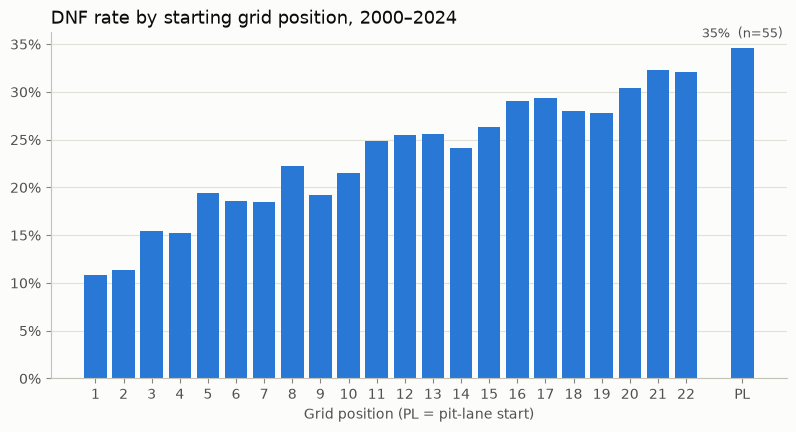

In [4]:
counts = df.groupby("grid").size()
shown_grids = [g for g in range(1, 23)]
rates = df[df.grid.isin(shown_grids)].groupby("grid")["dnf"].mean()
pl_rate = df[df.grid == 0]["dnf"].mean()

fig, ax = styled((9.5, 4.5))
positions = list(rates.index) + [24]           # gap before the pit-lane bar
ax.bar(positions[:-1], rates.values, color=BLUE, width=0.8)
ax.bar([24], [pl_rate], color=BLUE, width=0.8)
ax.set_xticks(positions)
ax.set_xticklabels([str(g) for g in rates.index] + ["PL"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_title("DNF rate by starting grid position, 2000–2024",
             color=INK, loc="left", fontsize=13)
ax.set_xlabel("Grid position (PL = pit-lane start)", color=INK2)
n_pl = counts.get(0, 0)
ax.annotate(f"{pl_rate:.0%}  (n={n_pl})", (24, pl_rate),
            textcoords="offset points", xytext=(0, 8), ha="center",
            color=INK2, fontsize=9)
save(fig, "dnf_rate_by_grid.png")
plt.show()

## 4. Accident vs mechanical DNFs over time

The two main retirement causes, each as a share of all entries per season — plus a
third line that exposes a **data-source break**: from 2023 onward the API records
almost every retirement as the generic status `Retired`, with no cause. The
detailed accident/mechanical split therefore *ends* after 2022; the causes didn't
vanish, the recording did. (Found while eyeballing the first version of this
chart, then confirmed in the raw statuses.)

saved /home/user/Formula-1-Retirement-Crash-Predictor/reports/figures/accident_vs_mechanical.png


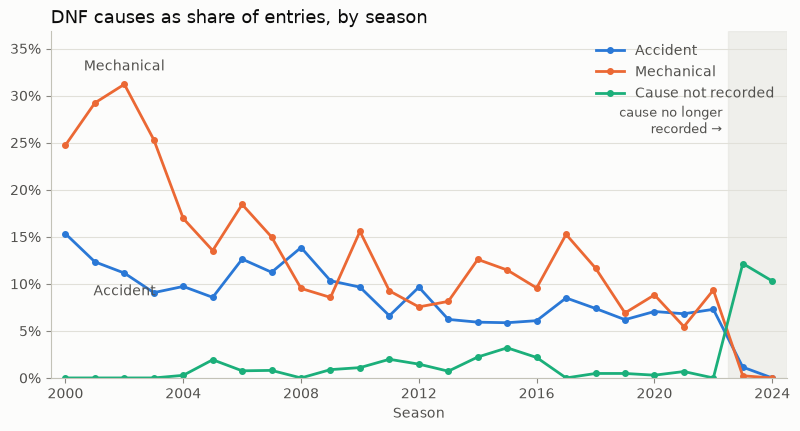

,accident,mechanical,cause not recorded
season,,,
2020,7.1%,8.8%,0.3%
2021,6.8%,5.5%,0.7%
2022,7.3%,9.3%,0.0%
2023,1.1%,0.2%,12.2%
2024,0.0%,0.0%,10.3%


In [5]:
AQUA = "#1baf7a"  # series 3
per_season = (
    df.assign(
        acc=df.dnf_category.eq("accident"),
        mech=df.dnf_category.eq("mechanical"),
        # generic 'Retired' rows plus the 'unknown' lap-gap retirements:
        # both are DNFs whose cause the source never recorded
        unrec=df.dnf & (df.dnf_category.eq("unknown")
                        | (df.label_unsure & df.dnf_category.eq("other"))),
    )
    .groupby("season")[["acc", "mech", "unrec"]].mean()
)

fig, ax = styled((9.5, 4.5))
ax.axvspan(2022.5, 2024.5, color=GRID, alpha=0.45, zorder=0)
ax.plot(per_season.index, per_season["acc"], color=BLUE, linewidth=2,
        marker="o", markersize=4, label="Accident")
ax.plot(per_season.index, per_season["mech"], color=ORANGE, linewidth=2,
        marker="o", markersize=4, label="Mechanical")
ax.plot(per_season.index, per_season["unrec"], color=AQUA, linewidth=2,
        marker="o", markersize=4, label="Cause not recorded")
ax.set_ylim(0, per_season.values.max() * 1.18)
ax.set_xlim(1999.5, 2024.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_title("DNF causes as share of entries, by season",
             color=INK, loc="left", fontsize=13)
ax.set_xlabel("Season", color=INK2)
ax.set_xticks(range(2000, 2025, 4))
# direct labels where the lines are well separated, plus the legend
ax.annotate("Mechanical", (2002, per_season.loc[2002, "mech"]),
            textcoords="offset points", xytext=(0, 10), ha="center",
            color=INK2, fontsize=10)
ax.annotate("Accident", (2002, per_season.loc[2002, "acc"]),
            textcoords="offset points", xytext=(0, -16), ha="center",
            color=INK2, fontsize=10)
ax.annotate("cause no longer\nrecorded \u2192", (2022.3, 0.26),
            ha="right", color=INK2, fontsize=9)
ax.legend(frameon=False, labelcolor=INK2, loc="upper right")
save(fig, "accident_vs_mechanical.png")
plt.show()

# Table view of the same numbers around the break
per_season.tail(5).rename(columns={
    "acc": "accident", "mech": "mechanical", "unrec": "cause not recorded"
}).style.format("{:.1%}")

## What the charts say (summary)

Written observations live in `EXPLANATION.md` (step two section) — in short:

1. **DNF rates fell from ~40% to ~11%** over the 25 seasons, so the era is a
   dominant signal and old seasons describe a different sport.
2. **Circuits differ a lot** (street/new circuits and chaotic venues at the top;
   Indianapolis is inflated by the 2005 six-car race).
3. **DNF risk rises almost monotonically with grid position**, and pit-lane
   starters are the riskiest group of all.
4. **From 2023 the source stops recording DNF causes** (everything is generic
   `Retired`), so the accident-vs-mechanical target can only be built through
   2022 without an extra data source.

All of this shapes the modeling decisions listed in `EXPLANATION.md`.